In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt

In [ ]:
# let's see what's inside the folder
base_path = '../data/raw/'

subreddits = [
    'GreenwashingSubreddit',
    'environmentSubreddit',
    'climateSubreddit',
    'climatechangeSubreddit',
    'sustainabilitySubreddit',
    'GreenSubreddit',
    'AnticonsumptionSubreddit',
    'ClimateActionPlanSubreddit',
    'ClimateOffensiveSubreddit',
    'SustainableFashionSubreddit',
    'ZeroWasteSubreddit'
]

for sub in os.listdir(base_path):
    sub_path = os.path.join(base_path, sub)
    if os.path.isdir(sub_path):
        print(f"\n{sub}:")
        print(os.listdir(sub_path))

In [3]:
# let's see what's inside TextPosts
print(os.listdir(base_path + 'GreenwashingSubreddit/TextPosts'))

['GreenwashingTextPosts.csv']


In [4]:
all_posts = []
for sub in subreddits:
    # builds the filename from the folder name
    filename = sub.replace('Subreddit', '') + 'TextPosts.csv'
    path = os.path.join(base_path, sub, 'TextPosts', filename)
    try:
        df = pd.read_csv(path)
        df['subreddit'] = sub
        all_posts.append(df)
        print(f"✓ {sub}: {len(df)} post")
    except FileNotFoundError:
        print(f"✗ {sub}: file not found - {path}")

df_all = pd.concat(all_posts, ignore_index=True)
print(f"\nTotal posts: {len(df_all)}")

# search for keywords
keywords = 'sunscreen|reef|coral|banana boat|hawaiian tropic|oxybenzone|reef-safe'
results = df_all[
    df_all['Title'].str.contains(keywords, case=False, na=False) |
    df_all['Text'].str.contains(keywords, case=False, na=False)
]

print(f"Relevant posts found: {len(results)}")
print(results[['subreddit', 'Title', 'Timestamp']].to_string())

✓ GreenwashingSubreddit: 69 post
✓ environmentSubreddit: 61 post
✓ climateSubreddit: 57 post
✓ climatechangeSubreddit: 158 post
✓ sustainabilitySubreddit: 455 post
✓ GreenSubreddit: 32 post
✓ AnticonsumptionSubreddit: 266 post
✓ ClimateActionPlanSubreddit: 20 post
✓ ClimateOffensiveSubreddit: 96 post
✓ SustainableFashionSubreddit: 258 post
✓ ZeroWasteSubreddit: 709 post

Total posts: 2181
Relevant posts found: 15
                        subreddit                                                                                                                                                           Title         Timestamp
137              climateSubreddit  If individual citizens had followed through with the eco-friendly campaigns back in the early 2000's, would there still be a major climate change issue today?  31/05/2019 12:58
153              climateSubreddit                          I struggle to understand how anyone who claims to be environmentally conscious believes that a trans

In [5]:
broad_keywords = (
    'sunscreen|sun screen|suncream|sun cream|sunblock|sun block|'
    'reef|coral|ocean|marine|'
    'oxybenzone|octinoxate|octocrylene|homosalate|avobenzone|chemical|toxic|'
    'greenwash|mislead|false|fake|lie|claim|'
    'banana boat|hawaiian tropic|edgewell|stream2sea|'
    'SPF|UV filter|skin care|skincare|beauty|cosmetic|lotion'
)

broad_results = df_all[
    df_all['Title'].str.contains(broad_keywords, case=False, na=False) |
    df_all['Text'].str.contains(broad_keywords, case=False, na=False)
]

print(f"Posts found: {len(broad_results)}")
print(broad_results[['subreddit', 'Title', 'Timestamp']].to_string())

Posts found: 848
                        subreddit                                                                                                                                                                                                                                                                                                      Title         Timestamp
0           GreenwashingSubreddit                                                                                                                                                                                                                                                                             The Other Kind of Greenwashing  20/06/2013 21:04
1           GreenwashingSubreddit                                                                                                                                                                                                                                         Behind the Gree

In [6]:
# look at the most relevant posts
mask = broad_results['Title'].str.contains(
    'sunscreen|cosmetic|beauty|skincare|skin care', 
    case=False, na=False
)
print(broad_results[mask][['Title', 'Text', 'Timestamp', 'subreddit']].to_string())

                                                                                                                                                                                                                                                          Title                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                         

In [7]:
df_comments = pd.read_csv(
    base_path + 'GreenwashingSubreddit/Comments/GreenwashingTextComments.csv'
)
print(df_comments.shape)
print(df_comments.columns.tolist())
print(df_comments.head(3))

(91, 10)
['Unnamed: 0', 'Type', 'Comment_id', 'Parent_id', 'Post_id', 'Author', 'Timestamp', 'Text', 'Score', 'Post_URL']
   Unnamed: 0     Type Comment_id  Parent_id Post_id        Author  \
0          75  Comment    fnf8vud  t3_g11ydz  g11ydz   kitsandkats   
1          89  Comment    g38vocn  t3_ieg1cb  ieg1cb  Homely_Homie   
2          91  Comment    gc72ul4  t3_jswvmn  jswvmn  Numismatists   

          Timestamp                                               Text  Score  \
0  14/04/2020 22:32  I recommend you post this to /r/SampleSize to ...      1   
1  29/08/2020 15:08  It's usually up to the investor to research th...      2   
2  13/11/2020 22:09  "At Compare Ethics, we believe knowledge is po...      1   

                                            Post_URL  
0  https://www.reddit.com/r/greenwashing/comments...  
1  https://www.reddit.com/r/greenwashing/comments...  
2  https://www.reddit.com/r/greenwashing/comments...  


In [8]:
all_comments = []
for sub in subreddits:
    filename = sub.replace('Subreddit', '') + 'TextComments.csv'
    path = os.path.join(base_path, sub, 'Comments', filename)
    try:
        df = pd.read_csv(path)
        df['subreddit'] = sub
        all_comments.append(df)
        print(f"✓ {sub}: {len(df)} comments")
    except FileNotFoundError:
        print(f"✗ {sub}: file not found")

df_all_comments = pd.concat(all_comments, ignore_index=True)
print(f"\nTotal comments: {len(df_all_comments)}")

# filter by relevant Post_ids
post_ids = broad_results['Post_id'].tolist()
relevant_comments = df_all_comments[
    df_all_comments['Post_id'].isin(post_ids)
]
print(f"Relevant comments: {len(relevant_comments)}")


✓ GreenwashingSubreddit: 91 comments
✓ environmentSubreddit: 741 comments
✓ climateSubreddit: 1433 comments
✓ climatechangeSubreddit: 26595 comments
✓ sustainabilitySubreddit: 18841 comments
✓ GreenSubreddit: 235 comments
✓ AnticonsumptionSubreddit: 26405 comments
✓ ClimateActionPlanSubreddit: 554 comments
✓ ClimateOffensiveSubreddit: 3643 comments
✓ SustainableFashionSubreddit: 3779 comments
✓ ZeroWasteSubreddit: 32247 comments

Total comments: 114564
Relevant comments: 33215


In [ ]:
# add column to distinguish posts from comments
broad_results['content_type'] = 'post'
relevant_comments['content_type'] = 'comment'

# align columns - keep only common ones
common_cols = ['Post_id', 'Author', 'Timestamp', 'Text', 'Score', 'subreddit', 'content_type']

df_final = pd.concat([
    broad_results[common_cols],
    relevant_comments[common_cols]
], ignore_index=True)

print(f"Final dataset: {len(df_final)} rows")
print(f"Posts: {len(df_final[df_final['content_type']=='post'])}")
print(f"Comments: {len(df_final[df_final['content_type']=='comment'])}")

# save
df_final.to_csv('../data/processed/greenwashing_dataset_filtered.csv', index=False)
print("✓ Saved!")

In [10]:
print(df_final.shape)
print(df_final.dtypes)
df_final.sample(20)

(34063, 7)
Post_id             str
Author              str
Timestamp           str
Text                str
Score           float64
subreddit           str
content_type        str
dtype: object


,Post_id,Author,Timestamp,Text,Score,subreddit,content_type
20142,1axdsof,Additional_Fun8797,22/02/2024 19:35,Ethically produced clothing is more expensive ...,1.0,AnticonsumptionSubreddit,comment
749,s72reg,mhbrown99q,18/01/2022 17:27,So reusable pads and period underwear are bann...,4.0,ZeroWasteSubreddit,post
8447,1fa0p36,BjLeinster,07/09/2024 14:11,The only people I know who believe climate cha...,1.0,climatechangeSubreddit,comment
6486,1asju6i,Zealousideal-Try6629,16/02/2024 22:34,In theory the jet fuel grade biofuels should c...,3.0,climatechangeSubreddit,comment
24236,pji2m7,twfo,07/09/2021 15:28,"I'll just leave this link here, as this Climat...",2.0,ClimateOffensiveSubreddit,comment
6335,1akh0c7,tomekelly,07/02/2024 8:43,Conservative news sources have really done a n...,3.0,climatechangeSubreddit,comment
8699,1ffgaz3,miked420dudemtg,13/09/2024 9:45,Enjoy your life responsibly :),0.0,climatechangeSubreddit,comment
13527,17klhf9,adinunzio22,01/11/2023 19:40,Watch the film 12 angry men if you believe 1 p...,1.0,sustainabilitySubreddit,comment
866,xv5xd4,atascon,04/10/2022 8:43,My feedback is that if you’re going to make or...,5.0,GreenwashingSubreddit,comment
10540,mekuj5,spades17,08/04/2021 21:01,[https://www.worldvision.org/hunger-news-stori...,1.0,sustainabilitySubreddit,comment


In [11]:
# drop Author column
df_final = df_final.drop(columns=['Author'])

# convert Timestamp to datetime
df_final['Timestamp'] = pd.to_datetime(df_final['Timestamp'], 
                                         dayfirst=True)

print(df_final.dtypes)
print(df_final.head(3))

Post_id                    str
Timestamp       datetime64[us]
Text                       str
Score                  float64
subreddit                  str
content_type               str
dtype: object
  Post_id           Timestamp  \
0  1gr3og 2013-06-20 21:04:00   
1  5x1vz1 2017-03-02 07:19:00   
2  cn3g3p 2019-08-07 09:13:00   

                                                Text  Score  \
0  The term "greenwashing" was originally used to...    2.0   
1  A critical look behind the green/sustainable f...    1.0   
2  I work for TerraCycle with Tom Szaky - our CEO...    2.0   

               subreddit content_type  
0  GreenwashingSubreddit         post  
1  GreenwashingSubreddit         post  
2  GreenwashingSubreddit         post  


In [ ]:
df_final.to_csv('../data/processed/greenwashing_dataset_filtered.csv', index=False)
print("✓ Saved!")

In [13]:
# missing text?
print(f"Rows with empty Text: {df_final['Text'].isna().sum()}")

# average text length
df_final['text_length'] = df_final['Text'].str.len()
print(f"\nAverage text length:")
print(df_final.groupby('content_type')['text_length'].describe().T)

Rows with empty Text: 0

Average text length:
content_type       comment          post
count         33215.000000    848.000000
mean            351.356767   1247.943396
std             479.562342   1564.860143
min               1.000000     13.000000
25%              94.000000    396.750000
50%             204.000000    767.500000
75%             420.000000   1460.000000
max            9933.000000  19240.000000


## Sanity Check

Comments average 351 characters, posts average 1248. 
This is expected: posts are longer original texts, 
comments are shorter replies.

High standard deviation (480 for comments, 1565 for posts) 
indicates high variability: some comments are as short as 
"Exactly!" (8 characters), others are essay-length.

Longest comment: 9,933 characters. Longest post: 19,240 characters.

In [14]:
# how many texts are too short?
print("Comments with fewer than 20 characters:")
print(df_final[
    (df_final['content_type'] == 'comment') & 
    (df_final['text_length'] < 20)
][['Text', 'text_length']].head(10))

Comments with fewer than 20 characters:
                     Text  text_length
855         Hhhmmm maybe🤔           13
856                Right!            6
912   Thank you so much!            19
923              I second            8
941            Thank you!           10
1047      Tetra Pak much?           15
1074       Answered above           14
1088          Hemp maybe?           11
1184               Cheers            6
1217         Wow, respect           12


In [15]:
total_comments = len(df_final[df_final['content_type']=='comment'])
short_comments = df_final[
    (df_final['content_type'] == 'comment') & 
    (df_final['text_length'] < 20)
]
print(f"Comments under 20 characters: {len(short_comments)}")
print(f"Percentage of total comments: {len(short_comments)/total_comments*100:.1f}%")

Comments under 20 characters: 1233
Percentage of total comments: 3.7%


## Text Length Filtering

Comments shorter than 20 characters (e.g. "Right!", "Thank you!", "🤞") 
were removed from the dataset. These entries carry no meaningful 
semantic content for NLP tasks — they contribute no signal to 
topic modeling or NER, and their sentiment value is negligible. 

This affected 1233 comments (18.1% of total comments). 
The 20-character threshold was chosen based on manual inspection 
of the shortest entries in the dataset.

In [ ]:
# drop comments that are too short
n_before = len(df_final)

df_final = df_final[
    ~((df_final['content_type'] == 'comment') & 
      (df_final['text_length'] < 20))
]

print(f"Dataset after cleaning: {len(df_final)} rows")
print(f"Removed: {n_before - len(df_final)} rows")

# save
df_final.to_csv('../data/processed/greenwashing_dataset_filtered.csv', index=False)
print("✓ Saved!")

content_type  comment  post
year                       
2010                1     1
2012               10     2
2013               23     4
2014               20     4
2015               69     3
2016              234     6
2017               15     3
2018              704    21
2019              976    57
2020             1282    83
2021             3739   144
2022             3834   143
2023            10560   159
2024             8391   181
2025             2124    37


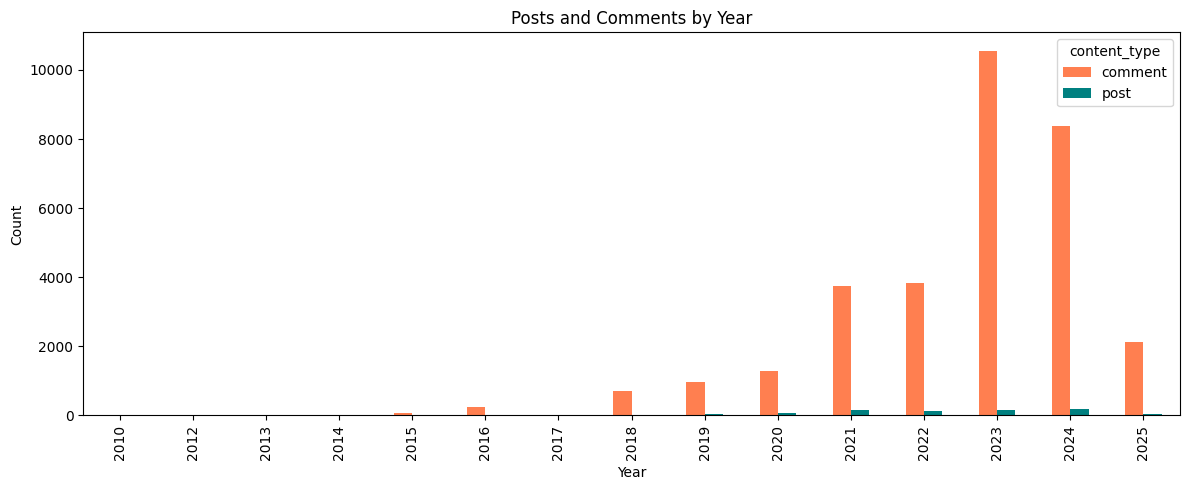

In [17]:
# extract year
df_final['year'] = df_final['Timestamp'].dt.year

# distribution by year
yearly = df_final.groupby(['year', 'content_type']).size().unstack(fill_value=0)
print(yearly)

# plot
yearly.plot(kind='bar', figsize=(12,5), color=['coral', 'teal'])
plt.title('Posts and Comments by Year')
plt.xlabel('Year')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [18]:
# which is the most commented post?
comments_per_post = df_final[df_final['content_type']=='comment'].groupby('Post_id').size().sort_values(ascending=False)
print(comments_per_post.head(5))

Post_id
177eiqv    1984
1fa0p36    1140
16w4y1d     750
1ib6amh     573
1hv0qok     570
dtype: int64


In [19]:
# find post 177eiqv
post_177 = df_final[
    (df_final['Post_id'] == '177eiqv') & 
    (df_final['content_type'] == 'post')
]['Text'].values

print(post_177)

<StringArray>
['At first I was against nuclear power, but the more I looked into it, I think it is the only way to combat climate change. \n\nRight now it is the only energy source with no CO2 emissions that can produce energy on the scale that people demand. Clearly the world is not interested in cutting emissions, so shouldn’t governments like the US, China, Russia and other nations with nuclear infrastructure build plants ASAP to cut back on fossil fuels? Why not create a power grid relying on  nuclear, solar, wind, geothermal, tidal, ect…?\n\nWe’ve basically mathematically missed the window to develop other “green” energy sources on a scale needed. Leaders should admit that nuclear energy is the only option. It can be a MASSIVE energy source.”\n\nAlso, yes, there is nuclear waste, but developing other clean sources like solar, contributes massive amounts of toxic waste.\n\nTo me, it seems like the least bad, practical option right now. Am I wrong? I honestly hope I am.']
Length: 1,

In [ ]:
# drop all records with Post_id 177eiqv
df_final = df_final[df_final['Post_id'] != '177eiqv']

print(f"Dataset after outlier removal: {len(df_final)} rows")

# save
df_final.to_csv('../data/processed/greenwashing_dataset_filtered.csv', index=False)
print("✓ Saved!")

## Outlier Detection: Post 177eiqv

Inspection of the most commented post (1,984 comments) revealed it was 
off-topic: a discussion about nuclear energy as a climate solution, 
not about greenwashing or reef-safe sunscreen.

The post matched our keyword filter due to incidental mentions of 
"clean", "toxic" and "emissions", but carries no relevant signal 
for this project.

Decision: remove all 1,985 records (1 post + 1,984 comments) 
associated with Post_id 177eiqv.

In [21]:
comments_per_post = df_final[df_final['content_type']=='comment'].groupby('Post_id').size().sort_values(ascending=False)
print(comments_per_post.head(10))

Post_id
1fa0p36    1140
16w4y1d     750
1ib6amh     573
1hv0qok     570
1fnz3te     569
oeo7ld      531
kygiom      522
13ssoar     452
17w1cp4     427
mekuj5      421
dtype: int64


In [22]:
for post_id in ['1fa0p36', '16w4y1d', '1ib6amh', '1hv0qok', '1fnz3te', 'oeo7ld', 'kygiom', '13ssoar', '17w1cp4', 'mekuj5']:
    testo = df_final[
        (df_final['Post_id'] == post_id) & 
        (df_final['content_type'] == 'post')
    ]['Text'].values
    titolo = df_final[
        (df_final['Post_id'] == post_id) & 
        (df_final['content_type'] == 'post')
    ].index
    print(f"\n--- Post {post_id} ---")
    if len(testo) > 0:
        print(testo[0][:1000])
    else:
        print("POST NOT FOUND (the original post was probably deleted)")


--- Post 1fa0p36 ---
what makes people not believe/distrust in science? what is the thought process here? who would even benefit from making it up? also, are all the scientific studies from around the world believed to be fake as well? i try to steer away from comments/posts/people who think like this, but i am genuinely curious to why they believe in conspiracies over data. is it worth trying to convince them that it is real? 

--- Post 16w4y1d ---
A recent post about animal agriculture vs plant based diets has me itching to say something. This is an issue we need to rise above.

Cognitive dissonance. 
Many of us have good intentions and want to believe we’re doing the right thing in most aspects of our lives. I believe that. 

When it comes to a plant based diet though, the science often clashes powerfully with personal desire. We want to minimize our impact on the environment and are willing to make trade-offs in our life time do so, but for many, giving up or even significantly re

In [ ]:
outliers_to_remove = ['1fa0p36', '16w4y1d', '1fnz3te', 'oeo7ld' ]

df_final = df_final[~df_final['Post_id'].isin(outliers_to_remove)]

print(f"Dataset after outlier removal: {len(df_final)} rows")

df_final.to_csv('../data/processed/greenwashing_dataset_filtered.csv', index=False)
print("✓ Saved!")

## Additional Outlier Removal

Inspected the top 5 most commented posts. Removed 3 off-topic posts:
- 1fa0p36: distrust in science (generic, not greenwashing-related)
- 16w4y1d: animal agriculture vs plant-based diets (off-topic)
- 1fnz3te and oeo7ld: climate change denial discussion (off-topic)

Retained:
- 1ib6amh: fast fashion and sustainable consumption (relevant)
- 1hv0qok: consumer frustration with sustainable pricing (relevant)

content_type  comment  post
year                       
2010                1     1
2012               10     2
2013               23     4
2014               20     4
2015               69     3
2016              234     6
2017               15     3
2018              704    21
2019              976    57
2020             1282    83
2021             3208   143
2022             3834   143
2023             7839   157
2024             6711   179
2025             2082    37


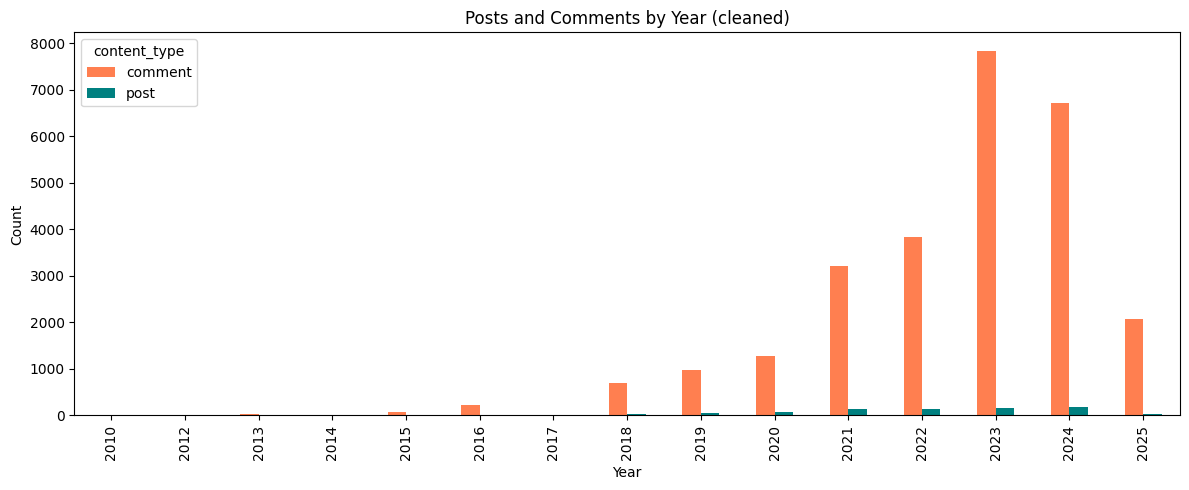

In [24]:
df_final['year'] = df_final['Timestamp'].dt.year

yearly = df_final.groupby(['year', 'content_type']).size().unstack(fill_value=0)
print(yearly)

yearly.plot(kind='bar', figsize=(12,5), color=['coral', 'teal'])
plt.title('Posts and Comments by Year (cleaned)')
plt.xlabel('Year')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## Temporal Distribution Analysis

The dataset spans 2010–2025, with a clear growth trend from 2020 onwards,
reflecting the rise of public awareness around greenwashing.

Key observations:
- Pre-2020 data is sparse and may be filtered out in further analysis
- 2021–2024 represents the most active period of discussion
- 2023 is the peak year (2,026 comments, 66 posts) after removing 
  the off-topic nuclear energy outlier (Post_id: 177eiqv)
- 2025 data is minimal: the dataset was collected before the ACCC 
  case against Edgewell/Banana Boat (July 2025), which represents 
  a key limitation for brand-specific analysis

This gap in 2025 data justifies the stratified synthetic augmentation 
strategy for brand-specific sunscreen content.